# PnPMass

This notebook runs PnPMass with uncertainty quantification (moment-2 network).

Install the `pycs` package from source (https://github.com/CosmoStat/cosmostat). Tested with commit nb `3eff4935bc3cd2368844c67452e429e0f4e7a127`.

In [1]:
%config InlineBackend.figure_format = 'svg'
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import random
import pickle
import numpy as np
from scipy import signal
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tensorflow import keras

from wlmmuq import CONFIG_DATA
import wlmmuq.utils as wlutils
import wlmmuq.batchloader as wlbl
import wlmmuq.kappatng as wlktng
import wlmmuq.cosmos as wlcosmos
import wlmmuq.iterativemm as wlpnp
import wlmmuq.cqr as wlcqr
import wlmmuq.ks93 as wlks93

2025-02-25 19:54:39.529937: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-25 19:54:39.530668: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-25 19:54:39.533130: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-25 19:54:39.540417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740509679.553173  337337 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740509679.55

Configuration file found in /home/leterme231/OneDrive/Documents/Code/weaklensing


In [3]:
# CHANGE PATH NAMES IF NEEDED
path_to_data = os.path.expanduser("~/Documents/Data")
path_to_keras = os.path.expanduser("~/Documents/Keras")

In [4]:
path_to_test_set = f"{path_to_data}/kappaTNG_cropped/LP001_cropped.hdf5"
path_to_models = f"{path_to_keras}/Denoiser/models"
path_to_stats = f"{path_to_keras}/Denoiser/stats"

In [5]:
random.seed(42)
np.random.seed(42)

## Load COSMOS galaxy shape catalog

In [6]:
imgsize = 304

In [7]:
cat_cosmos_bright, _ = wlcosmos.cosmos_catalog()
cat_cosmos_bright = wlktng.filter_by_redshifts(cat_cosmos_bright)
data_dict = wlktng.get_data_from_cosmos_ktng(cat_cosmos_bright, imgsize)
extent = data_dict["extent"]

In [8]:
ra, dec = np.array(wlcosmos.COSMOS_VERTICES).T

In [9]:
shapedisp = data_dict["shapedisp"]
ngal = data_dict["ngal"]
mask = data_dict["mask"]
std_noise = wlutils.get_std_noise(ngal, shapedisp, std_noise_mask=0)

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/utils.py:137: RuntimeWarning: divide by zero encountered in divide
  shapedisp / np.sqrt(ngal), posinf=std_noise_mask


In [10]:
print(f"Min noise standard deviation = {np.min(std_noise[mask]):.2e}")

Min noise standard deviation = 7.40e-02


The step size must be smaller than $2\sigma_0$, where $\sigma_0$ is computed above.

## Results training order-2 moment network

Trained on GPU cluster using `./bash/train_denoiser_variance.sh <GPU_ID> <PRED_DATASET> <SCALE> <TRAINING_DATE> <LEARNING_RATE>`.
- Size of the training set: 70560
- Batch size: 32
- Number of epochs: 20
- Scale: 1.4e-1 (large noise)
- Learning rate: 1e-4, decreased by a factor of 10 every 5 epochs

### Training and validation loss

In [11]:
dirname_var = '1_40e_01_20241118_183322'

In [12]:
df_var = pd.read_csv(os.path.join(path_to_stats, f'log_denoiser_{dirname_var}_var.csv'))

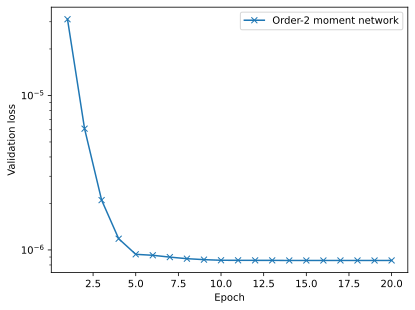

In [13]:
plt.plot(df_var['epoch'] + 1, df_var['val_loss'], label='Order-2 moment network', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.legend()
plt.yscale('log')
plt.show()

### Results on the test set

In [14]:
nimgs_test = 225
offset = 0.5 # Offset used during training
std_large = 1.4e-1

In [15]:
test_gen_largescale = wlbl.HDF5BatchLoaderDenoiser(
    order=1, hdf5_filepath=path_to_test_set, nimgs=nimgs_test,
    scale=std_large, shuffle=False, output_shape=imgsize
)

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/batchloader.py:138: UserWarning: The 'filename_ori' dataset is missing; input images will not be sorted.
  warnings.warn(


In [16]:
kappa_largenoise_test, kappa_test = test_gen_largescale.load_batch(get_all_images=True)

In [17]:
vmin = np.min(kappa_test)
vmax = np.max(kappa_test)
saturation = 0.4

In [18]:
idx = 0

In [19]:
# Initial learning rate set to 1e-4
model_var = keras.models.load_model(
    os.path.join(path_to_models, f'denoiser_{dirname_var}_var_e20.keras')
)
denoiser_var = wlpnp.KerasDenoiserVar(model_var, offset=offset)

W0000 00:00:1740509689.482181  337337 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [20]:
std_kappa_denoised_test = np.sqrt(denoiser_var(kappa_largenoise_test))

I0000 00:00:1740509690.235408  337587 service.cc:148] XLA service 0x749a48010e20 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1740509690.235451  337587 service.cc:156]   StreamExecutor device (0): Host, Default Version
2025-02-25 19:54:50.254896: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1740509690.464210  337587 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 551ms/step


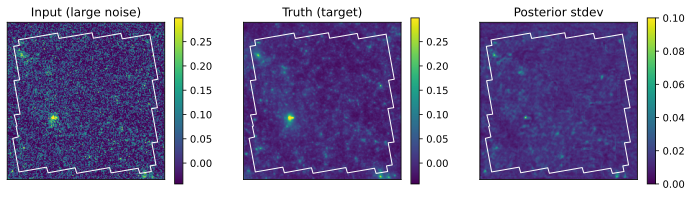

In [21]:
plt.figure(figsize=(12, 3))
plt.subplot(131)
wlutils.skyshow(
    kappa_largenoise_test[idx], title="Input (large noise)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(132)
wlutils.skyshow(
    kappa_test[idx], title="Truth (target)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(133)
wlutils.skyshow(
    std_kappa_denoised_test[idx], title="Posterior stdev",
    vmin=0., vmax=0.1, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.show()

In [22]:
del kappa_largenoise_test
del std_kappa_denoised_test

## PnP mass mapping with UQ

In [23]:
niter = 8

#### Load test set

In [24]:
test_gen = wlbl.HDF5BatchLoaderGammaKappa(
    path_to_test_set, nimgs=nimgs_test, std_noise=std_noise, mask=mask, shuffle=False,
    output_shape=imgsize, list_of_outputs=['gamma1', 'gamma2', 'gamma1_noisy', 'gamma2_noisy', 'kappa_true']
)

In [25]:
gamma1_test, gamma2_test, gamma1_noisy_test, gamma2_noisy_test, kappa_test = \
    test_gen.load_batch(get_all_images=True)
gamma_noisy_test = gamma1_noisy_test + 1j * gamma2_noisy_test

In [26]:
vmax_gamma = max(
    -np.min(gamma1_test), -np.min(gamma2_test),
    np.max(gamma1_test), np.max(gamma2_test)
)
saturation_gamma = 0.6
del gamma1_test
del gamma2_test

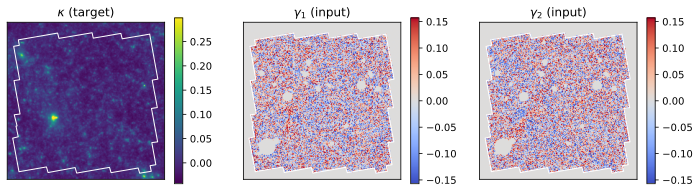

In [27]:
plt.figure(figsize=(12, 3))
# Convergence map
plt.subplot(131)
wlutils.skyshow(
    kappa_test[idx], vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True, title=r"$\kappa$ (target)"
)
# Shear map (noisy)
plt.subplot(132)
wlutils.skyshow(
    gamma1_noisy_test[idx],
    cmap="coolwarm", vmin=-saturation_gamma*vmax_gamma, vmax=saturation_gamma*vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True, title=r"$\gamma_1$ (input)"
)
plt.subplot(133)
wlutils.skyshow(
    gamma2_noisy_test[idx],
    cmap="coolwarm", vmin=-saturation_gamma*vmax_gamma, vmax=saturation_gamma*vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True, title=r"$\gamma_2$ (input)"
)
plt.show()

In [28]:
del gamma1_noisy_test
del gamma2_noisy_test

#### Load denoiser (point estimate)

In [29]:
dirname_largescale = '1_40e_01_20241118_183322'

In [30]:
# Initial learning rate set to 1e-4
model = keras.models.load_model(
    os.path.join(path_to_models, f'denoiser_{dirname_largescale}_pe_e20.keras')
)
denoiser = wlpnp.KerasDenoiser(model, offset=offset)

#### Instantiate PGD mass mapping

In [31]:
pnp = wlpnp.PGDMassMapping(
    std_noise=std_noise, step_size=std_large**2,
    backward=denoiser, niter=niter, mask=mask
)

In [32]:
# Callbacks
show_intermediate_maps = wlpnp.ShowIntermediateMaps(
    idx, showevery=2, vmin=vmin, vmax=saturation*vmax,
    extent=extent, boundaries=(ra, dec)
)
rmse_largescale = wlpnp.RMSE(
    kappa_true=kappa_test, mask=mask
)
posterior_variance = wlpnp.UQ(pnp, denoiser_var, gamma_noisy_test)

callbacks = [
    show_intermediate_maps, rmse_largescale, posterior_variance
]

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/iterativemm.py:64: RuntimeWarning: invalid value encountered in divide
  resgamma /= self.var_noise


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 541ms/step


/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/iterativemm.py:64: RuntimeWarning: divide by zero encountered in divide
  resgamma /= self.var_noise


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step


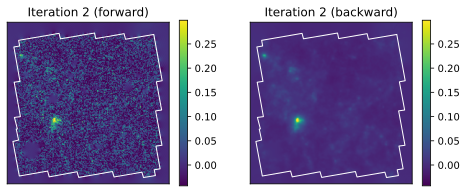

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 488ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 485ms/step


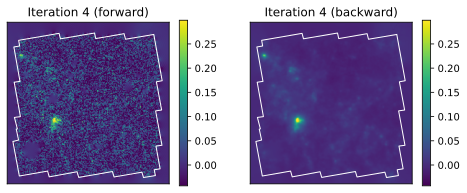

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 486ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 459ms/step


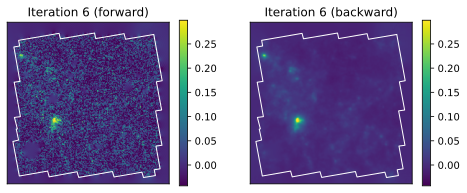

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 454ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 487ms/step


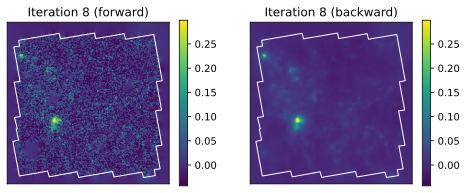

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 467ms/step


In [33]:
kappa_pnp_test = pnp(
    gamma_noisy_test, callbacks=callbacks
)

### Point estimate

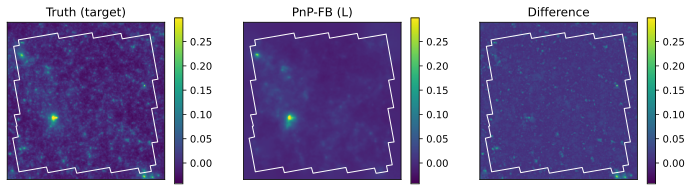

In [34]:
plt.figure(figsize=(12, 3))
plt.subplot(131)
wlutils.skyshow(
    kappa_test[idx], title="Truth (target)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(132)
wlutils.skyshow(
    kappa_pnp_test[idx], title="PnP-FB",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(133)
wlutils.skyshow(
    np.abs(kappa_test[idx] - kappa_pnp_test[idx]), title="Difference",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.show()

In [35]:
mse_pnp_test = wlutils.rmse(
    kappa_pnp_test, kappa_test, mask=mask
)

In [36]:
om = 3
print(
    f"PnP-FB, large noise level --> RMSE = {10**om * np.mean(mse_pnp_test):.2f}e-{om} "
    f"+/- {1e3*np.std(mse_pnp_test):.2f}e-{om}"
)

PnP-FB, large noise level --> RMSE = 17.45e-3 +/- 0.88e-3


### UQ

#### UQ parameters

In [37]:
confidence = 2. # Level of confidence (n-sigma)
alpha = wlutils.get_alpha_from_confidence(confidence)

min_nimgs_calib = wlutils.get_min_nimgs_calib(alpha)
print(f"Confidence level of {confidence}-sigma --> alpha = {alpha:.1%}")
print(f"Smallest possible size for the calibration set = {min_nimgs_calib}")

Confidence level of 2.0-sigma --> alpha = 4.6%
Smallest possible size for the calibration set = 21


In [38]:
nimgs_calib = 100
nimgs_test -= nimgs_calib

#### Get residuals

In [39]:
std_pnp_test = np.sqrt(posterior_variance.kappa_uq)
res_pnp_test = confidence * std_pnp_test

#### Split test and calibration sets

In [40]:
[
    kappa_calib, kappa_pnp_calib, res_pnp_calib
], [
    kappa_test, kappa_pnp_test, res_pnp_test
] = wlutils.split_test_calib(
    [kappa_test, kappa_pnp_test, res_pnp_test],
    nimgs_calib, calib_first=False
) # First the test set; then the calibration set

print(f"Size of the calibration set = {kappa_calib.shape[0]}")
print(f"Size of the test set = {kappa_test.shape[0]}")

Size of the calibration set = 100
Size of the test set = 125


### CQR

In [41]:
addcqr = wlcqr.AddCQR(alpha)

In [42]:
res_pnp_addcqr_test, _, _ = addcqr.conformalize(
    res_pnp_test, kappa_pnp_calib, res_pnp_calib, kappa_calib
)

#### Miscoverage rate (all pixels)

In [43]:
def get_metrics(pred, res, **kwargs):

    kappa_lo = pred - res
    kappa_hi = pred + res

    # Error rate per image (over pixels)
    err = wlutils.miscoverage_rate(
        kappa_lo, kappa_hi, kappa_test, **kwargs
    )

    # Mean length of prediction intervals
    predinterv = wlutils.mean_predinterv(
        kappa_lo, kappa_hi, **kwargs
    )

    # Mean value for the lower and upper bounds
    lower = wlutils.mean_val(kappa_lo, **kwargs)
    upper = wlutils.mean_val(kappa_hi, **kwargs)

    return err, predinterv, lower, upper

In [45]:
def plot_means_errs(
        list_of_means, list_of_stds, list_of_methods, xticklabels=None, sec_xticklabels=None,
        xlabel=None, ylabel=None, drawtarget=True, drawbounds=True,
        y_lower=None, y_upper=None, logscale=False, ymin=None, ymax=None, loclegend=None,
        figsize=(6, 3), savefig=False, filepath=None, filename=None, extension=None
):
    """
    Plot means with error bars representing standard deviations
    
    """
    nseries = len(list_of_means)
    assert len(list_of_stds) == nseries
    if xticklabels is not None:
        nvals = len(xticklabels)
    else:
        nvals = 1
    offset = 0.15  # Adjust the offset as needed

    _, ax = plt.subplots(figsize=figsize)
    for i, (means, stds, label) in enumerate(zip(list_of_means, list_of_stds, list_of_methods)):
        x_values = np.arange(nvals) + 1 + (i - (nseries - 1) / 2) * offset  # Adjusted x-coordinates
        plt.errorbar(x_values, means, yerr=stds, fmt='.', capsize=3, label=label)

    if xticklabels is not None:
        plt.xticks(np.arange(nvals) + 1, xticklabels, rotation=45)
    else:
        plt.xticks([])
    ax.set_xlim(0.5, nvals + 0.5)

    if sec_xticklabels is not None:
        sec_nvals = len(sec_xticklabels)
        sec_xticks = nvals / sec_nvals * np.arange(sec_nvals) + (nvals / sec_nvals + 1) / 2
        sec = ax.secondary_xaxis(location=0)
        sec.set_xticks(sec_xticks, labels=sec_xticklabels)
        sec.tick_params('x', length=0)

        # lines between the classes:
        sec_xticks = nvals / sec_nvals * np.arange(sec_nvals + 1) + 0.5
        sec2 = ax.secondary_xaxis(location=0)
        sec2.set_xticks(sec_xticks, labels=[])
        sec2.tick_params('x', length=50, width=1)

    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)
    if drawtarget:
        plt.axhline(y=alpha, color='red', linestyle='--', linewidth=0.8, label=r'$\alpha$ (target)')
    if drawbounds:
        plt.axhspan(
            y_lower, y_upper,
            color='yellow', alpha=0.3, linewidth=0., label=r"Theoretical bounds for $\mathrm{\mathbb{E}}[L]$"
        )
    plt.legend(loc=loclegend)
    if logscale:
        plt.yscale('log')
    kwargs = {}
    if ymin is not None:
        kwargs.update(bottom=ymin)
    if ymax is not None:
        kwargs.update(top=ymax)
    if kwargs != {}:
        plt.ylim(**kwargs)
    if savefig:
        plt.savefig(os.path.join(filepath, f"{filename}.{extension}"), bbox_inches='tight')

    plt.show()

In [46]:
ylabel_err = \
    r"$L\left(\boldsymbol{\kappa}_i,\, \hat{\boldsymbol{\kappa}}_i^-,\, \hat{\boldsymbol{\kappa}}_i^+\right)$"

In [47]:
xticklabels = ['Uncalibrated', 'Additive CQR']

In [48]:
lower_bound_proba, upper_bound_proba = addcqr.get_bounds_proba(nimgs_calib)

In [49]:
err_pnp_test, _, _, _ = get_metrics(
    kappa_pnp_test, res_pnp_test, mask=mask
)
err_pnp_addcqr_test, _, _, _ = get_metrics(
    kappa_pnp_test, res_pnp_addcqr_test, mask=mask
)

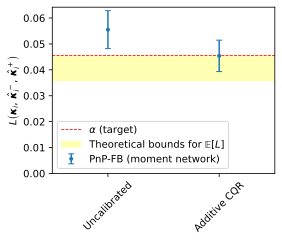

In [50]:
plot_means_errs(
    [[np.mean(err_pnp_test), np.mean(err_pnp_addcqr_test)]],
    [[np.std(err_pnp_test), np.std(err_pnp_addcqr_test)]],
    ['PnP-FB (moment network)'], xticklabels=xticklabels,
    ylabel=ylabel_err, drawbounds=True, y_lower=lower_bound_proba, y_upper=upper_bound_proba,
    ymin=0.0, figsize=(4, 3), logscale=False, savefig=False,
    filename='err_pnp'
)

#### High-density regions

In [51]:
mean_std_noise = wlutils.mean_val(std_noise, mask=mask)

In [52]:
std_blurringfilter = None
min_snr = 0.25
minval_kappa = min_snr * mean_std_noise

In [53]:
n_highdensity_pixels = kappa_test[kappa_test >= minval_kappa].size
n_pixels = kappa_test.size
print(
    f"{n_highdensity_pixels} pixels above {minval_kappa:.1e} "
    f"({n_highdensity_pixels / n_pixels:.2%} of total)"
)

330698 pixels above 4.8e-02 (2.86% of total)


In [54]:
mask_highdensity = (np.abs(kappa_test) >= minval_kappa) * mask

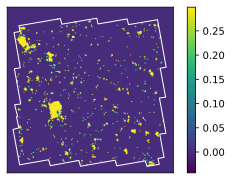

In [55]:
plt.figure(figsize=(5, 3))
wlutils.skyshow(
    mask_highdensity[idx], vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False
)
plt.show()

In [56]:
mse_pnp_test_hd = wlutils.rmse(kappa_pnp_test, kappa_test, mask=mask_highdensity)

In [57]:
om = 3
print(
    f"PnP-FB, high-density regions --> RMSE = {10**om * np.mean(mse_pnp_test_hd):.1f}e-{om} "
    f"+/- {1e3*np.std(mse_pnp_test_hd):.1f}e-{om}"
)

PnP-FB, high-density regions --> RMSE = 66.1e-3 +/- 3.3e-3


#### Miscoverage rate (high-density regions)

In [58]:
err_pnp_test_hd, _, _, _ = get_metrics(
    kappa_pnp_test, res_pnp_test, mask=mask_highdensity
)
err_pnp_addcqr_test_hd, _, _, _ = get_metrics(
    kappa_pnp_test, res_pnp_addcqr_test, mask=mask_highdensity
)

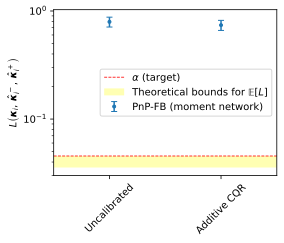

In [59]:
plot_means_errs(
    [[np.mean(err_pnp_test_hd), np.mean(err_pnp_addcqr_test_hd)]],
    [[np.std(err_pnp_test_hd), np.std(err_pnp_addcqr_test_hd)]],
    ['PnP-FB (moment network)'], xticklabels=xticklabels,
    ylabel=ylabel_err, drawbounds=True, y_lower=lower_bound_proba, y_upper=upper_bound_proba,
    ymin=0.03, figsize=(4, 3), logscale=True, savefig=False
)